# Fluorescence Data Analysis
This notebook loads spectral data from `.ods` files and ... different materials: **Fluoresceine**, **Rhodamine B**, and **Rhodamine 6G**.

### Imports and Configuration

In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Set visual theme
sns.set_theme(style="whitegrid")
X_font = {"fontsize": 12, "fontweight": "bold"}
Y_font = {"fontsize": 12, "fontweight": "bold"}
Title_font = {"fontsize": 14, "fontweight": "bold"}
legend_font = {"fontsize": 10, "fontweight": "bold"}

# Configuration
DATA_DIR = "data"
SHEET_NAMES = ["Fluoresceine", "Rhodamine B", "Rhodamine 6G"]

## 1. Data Loading Phase
We scan the data directory, read each sheet for every `.ods` file, and organize them into a nested dictionary structure: `data_storage[material][file_name] = dataframe`.

In [10]:
def read_data(file_path, sheet_name):
    return pd.read_excel(file_path, sheet_name=sheet_name, engine="odf")


# Initialize dictionary structure to hold data
# Format: { 'Fluoresceine': { 'file1.ods': df, 'file2.ods': df }, ... }
data_storage = {material: {} for material in SHEET_NAMES}

if os.path.exists(DATA_DIR):
    files = os.listdir(DATA_DIR)
    paths = [os.path.join(DATA_DIR, f) for f in files if f.endswith(".ods")]

    for path in paths:
        file_name = os.path.basename(path)
        for sheet in SHEET_NAMES:
            try:
                df = read_data(path, sheet)
                data_storage[sheet][file_name] = df
            except Exception as e:
                print(f"Warning: Missing or corrupt sheet '{sheet}' in {file_name}. Error: {e}")
    print(f"Successfully loaded data from {len(paths)} file(s).")
else:
    print(f"Error: Directory '{DATA_DIR}' not found. Please verify your folder path.")

Successfully loaded data from 5 file(s).


## 2. Raw Data Visualization

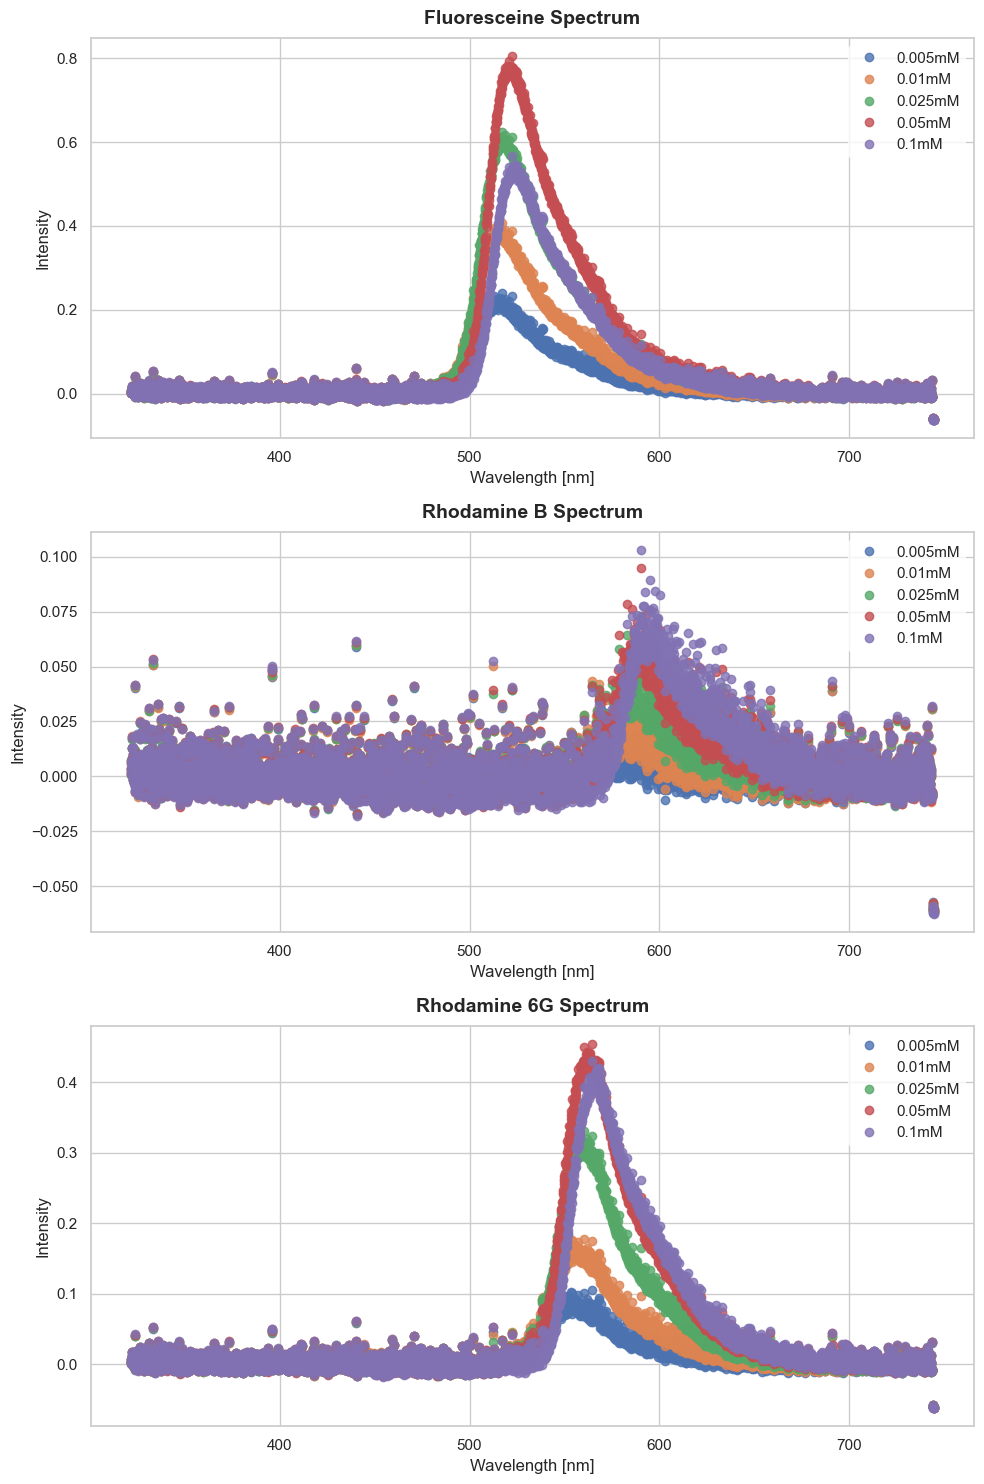

In [12]:
# 3-row, 1-column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15), sharex=False)

for i, sheet in enumerate(SHEET_NAMES):
    ax = axes[i]
    material_data = data_storage[sheet]

    for file_name, df in material_data.items():
        x_col = "X [nm (air)]"
        y_col = "Y [Intensity]"

        if x_col in df.columns and y_col in df.columns:
            label_name = file_name.replace(".ods", "").replace("_", ".")
            ax.plot(df[x_col], df[y_col], 'o', label=label_name, alpha=0.8, linewidth=1.5)
        else:
            print(f"Column mismatch in {file_name} for sheet {sheet}")
    
    ax.set_title(f"{sheet} Spectrum", fontsize=Title_font["fontsize"], fontweight="bold", pad=10)
    ax.set_ylabel("Intensity", fontsize=Y_font["fontsize"])
    ax.set_xlabel("Wavelength [nm]", fontsize=Y_font["fontsize"])

    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()

plt.savefig("figures/spectrum.png", dpi=300, bbox_inches="tight")
plt.show()

### Trapezoidal Rule

For a set of $n$ discrete data points, the total integrated spectrum area ($I$) is approximated by summing adjacent trapezoids:

$$I = \sum_{k=0}^{n-2} \frac{y_k + y_{k+1}}{2} (x_{k+1} - x_k)$$

When expanded, this can be written as a linear combination of weights ($w_i$) and intensity values ($y_i$):

$$I = \sum_{i=0}^{n-1} w_i y_i$$

Where the structural geometric weights are defined as:
* **First point ($w_0$):** $\frac{x_1 - x_0}{2}$
* **Last point ($w_{n-1}$):** $\frac{x_{n-1} - x_{n-2}}{2}$
* **Interior points ($w_k$):** $\frac{x_{k+1} - x_{k-1}}{2}$

---

### Integration Uncertainty

By applying the Law of Propagation of Uncertainty for independent and identically distributed random baseline noise ($\sigma_y$), the propagated uncertainty of the integrated area ($\sigma_I$) is calculated as:

$$\sigma_I = \sqrt{ \left(\frac{x_1 - x_0}{2}\right)^2 \sigma_{y,0}^2 + \sum_{k=1}^{n-2} \left(\frac{x_{k+1} - x_{k-1}}{2}\right)^2 \sigma_{y,k}^2 + \left(\frac{x_{n-1} - x_{n-2}}{2}\right)^2 \sigma_{y,n-1}^2 }$$

Assuming uniform detector noise across the spectrum ($\sigma_{y,i} = \sigma_y$), this factors out cleanly to match the numerical execution loop:

$$\sigma_I = \sigma_y \sqrt{ \sum_{i=0}^{n-1} w_i^2 }$$

In [ ]:
import numpy as np

X_CUTOFF = 470  # Integration starting from X_CUTOFF 

integration_results = {material: [] for material in SHEET_NAMES}

for sheet in SHEET_NAMES:
    material_data = data_storage[sheet]

    for file_name, df in material_data.items():
        x_col = "X [nm (air)]"
        y_col = "Y [Intensity]"

        if x_col in df.columns and y_col in df.columns:
            # ensuring the data is sorted in order to do trapeziod rule integration
            df_sorted = df.sort_values(by=x_col)

            # --- ESTIMATE BASELINE NOISE ---
            baseline_mask = df_sorted[x_col] <= 400
            baseline_points = df_sorted[baseline_mask][y_col]

            sigma_y = baseline_points.std()


            if np.isnan(sigma_y) or sigma_y == 0:
                print(f"Warning: Baseline noise estimation failed for {file_name} ({sheet}). Using 1% of max intensity as fallback.")
                sigma_y = 0.01 * df_sorted[y_col].max()

            # Filter data from X_CUTOFF to the end for integration
            mask = df_sorted[x_col] >= X_CUTOFF
            df_filtered = df_sorted[mask]

            x_vals = df_filtered[x_col].to_numpy()
            y_vals = df_filtered[y_col].to_numpy()
            n = len(x_vals)

            if n > 1:
                # 1. Calculate Integrated Area
                integrated_val = np.trapz(y_vals, x=x_vals)

                # 2. Calculate propagated uncertainty 
                dx = np.diff(x_vals)
                weights = np.zeros(n)
                weights[0] = dx[0] / 2
                weights[-1] = dx[-1] / 2
                weights[1:-1] = (dx[:-1] + dx[1:]) / 2

                # Integrated variance = sum(w_i^2 * sigma_y^2)
                propagated_variance = np.sum((weights**2) * (sigma_y**2))
                uncertainty_val = np.sqrt(propagated_variance)

                label_name = file_name.replace(".ods", "").replace("_", ".")
                conc_str = label_name.replace("mM", "")
                concentration_val = float(conc_str)

                integration_results[sheet].append(
                    {
                        "file": file_name,
                        "concentration": concentration_val,
                        "integrated_intensity": integrated_val,
                        "uncertainty": uncertainty_val,
                    }
                )
            else:
                print(
                    f"Skipping {file_name} ({sheet}): Not enough data points above {X_CUTOFF} nm."
                )

print("Integration and uncertainty propagation completed.")

Integration and uncertainty propagation completed.


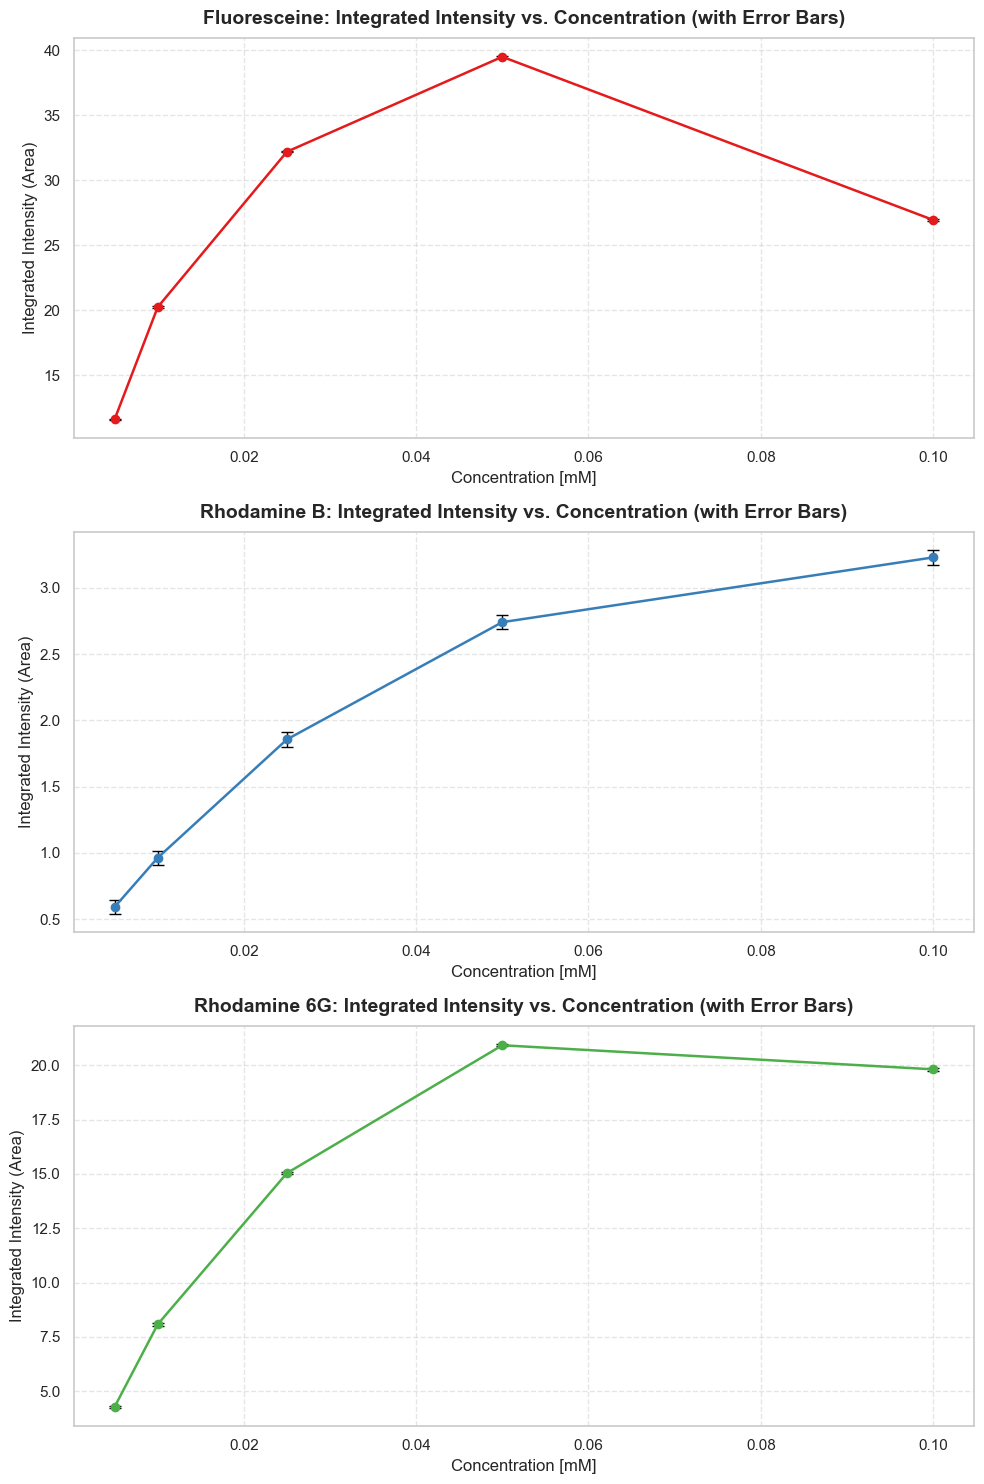

In [ ]:
# 3-row, 1-column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15), sharex=True)

for i, sheet in enumerate(SHEET_NAMES):
    ax = axes[i]
    results_list = integration_results[sheet]

    if not results_list:
        print(f"No integrated data found for {sheet}")
        continue

    df_plot = pd.DataFrame(results_list)
    df_plot = df_plot.sort_values(by="concentration")

    ax.errorbar(
        df_plot["concentration"],
        df_plot["integrated_intensity"],
        yerr=df_plot["uncertainty"],
        fmt="o-",  
        markersize=6,
        linewidth=1.8,
        capsize=4, 
        ecolor="black",  
        elinewidth=1,
        label=sheet,
        color=sns.color_palette("Set1")[i],
    )

    ax.set_title(
        f"{sheet}: Integrated Intensity vs. Concentration (with Error Bars)",
        fontsize=Title_font["fontsize"],
        fontweight="bold",
        pad=10,
    )
    ax.set_ylabel("Integrated Intensity (Area)", fontsize=Y_font["fontsize"])
    ax.set_xlabel("Concentration [mM]", fontsize=X_font["fontsize"])
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig(
    "figures/intensity_vs_concentration_uncertainty.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()